In [ ]:
"""
Algorithm 7
Counting Sort

Victor Morgan and Ahmed Abdallah
04/26/2026
"""

<p align = "center" text> <b>Algorithm Description</b></p>

Algorithm 7 is a classic implementation of Counting Sort.

**How it works**:   

1. It creates a secondary "scoreboard" array (B) that is initialized with all zeros.It walks through your original array (A). 
2. If it sees the number 5, it goes to index 5 on the scoreboard and adds a tally mark (B[A[i]]++).
3. Once it finishes tallying, it doesn't need the original array's order anymore. It just walks down the scoreboard from lowest to highest. If the scoreboard says the number 0 has 2 tallies, it writes 0, 0 back into the array. If 1 has no tallies, it skips it. If 2 has one tally, it writes 2, and so on.   


**Limitation**:   
 Because the scoreboard B is created with size $N$, this specific algorithm assumes that every number in array A is strictly between $1$ and $N$ (or $0$ and $N-1$ in Python). If array A had the number 1,000,000 but only had 10 items in it, the algorithm would crash trying to find index 1,000,000 on a scoreboard of size 10.



<p align = "center" text> <b>Algorithm Implementation</b></p>

In [17]:
def algorithm_7(A):
    N = len(A)
    if N == 0: 
        return
        
    B = [0] * N 
    
    for i in range(N):
        B[A[i]] += 1
        
    i = 0
    for j in range(N):
        for k in range(B[j]):
            A[i] = j
            i += 1

<p align = "center" text> <b>Time Complexity Analysis</b></p>  

Initalization $\rightarrow$ $O(N)$   
Index Incrementation $\rightarrow$ $O(N)$   
Reconstruction $\rightarrow$ $O(N)$   

**Overall Time Complexity**: $\Theta(N)$   
Everything adds up to $3N$, which simplifies asymptotically to linear $O(N)$ time.

Best Case: $\Theta(N)$   
Worst Case: $\Theta(N)$


<p align = "center" text> <b>Benchmark and Conclusion</b></p>

In [ ]:
import time
import random
import matplotlib.pyplot as plt
def benchmark():
    sizes = [100, 500, 1000, 5000, 10000, 50000, 100000]
    replications = 50
    
    random_times = []
    sorted_times = []
    reversed_times = []
    
    print("Testing O(N) Algorithm 7 (Counting Sort)...")
    print(f"{'Size (N)':<12} | {'Random (s)':<12} | {'Sorted (s)':<12} | {'Reversed (s)':<12}")
    print("-" * 55)
    
    for N in sizes:
        times = {"Random": 0, "Sorted": 0, "Reversed": 0}
        
        for _ in range(replications):
            arr_sorted = list(range(N))
            arr_reversed = arr_sorted[::-1]
            arr_random = arr_sorted[:]
            random.shuffle(arr_random)
            
            # Random
            start = time.perf_counter()
            algorithm_7(arr_random)
            times["Random"] += time.perf_counter() - start
            
            # Sorted
            start = time.perf_counter()
            algorithm_7(arr_sorted)
            times["Sorted"] += time.perf_counter() - start
            
            # Reversed
            start = time.perf_counter()
            algorithm_7(arr_reversed)
            times["Reversed"] += time.perf_counter() - start
            
        avg_rand = times["Random"] / replications
        avg_sort = times["Sorted"] / replications
        avg_rev = times["Reversed"] / replications
        
        print(f"{N:<12} | {avg_rand:<12.5f} | {avg_sort:<12.5f} | {avg_rev:<12.5f}")
        
        # Save data for the plot
        random_times.append(avg_rand)
        sorted_times.append(avg_sort)
        reversed_times.append(avg_rev)

    print("\nGenerating plot...")
    plt.figure(figsize=(10, 6))
    
    # Draw the lines
    plt.plot(sizes, random_times, marker='o', color='blue', label='Random Data')
    plt.plot(sizes, sorted_times, marker='s', color='green', label='Sorted Data')
    plt.plot(sizes, reversed_times, marker='^', color='red', label='Reversed Data')
    
    # Formatting
    plt.title("Algorithm 7 Execution Time vs. Array Size (O(N) Complexity)", fontsize=14, fontweight='bold')
    plt.xlabel("Array Size (N)", fontsize=12)
    plt.ylabel("Execution Time (Seconds)", fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.ticklabel_format(style='plain', axis='x') 
    
    # Save the file and display it
    plt.tight_layout()
    plt.savefig("algorithm7_runtime_plot.png", dpi=300)
    plt.show()

Testing O(N) Algorithm 7 (Counting Sort)...
Size (N)     | Random (s)   | Sorted (s)   | Reversed (s)
-------------------------------------------------------
100          | 0.00002      | 0.00002      | 0.00002     
500          | 0.00012      | 0.00012      | 0.00012     
1000         | 0.00023      | 0.00024      | 0.00024     
5000         | 0.00121      | 0.00122      | 0.00121     
10000        | 0.00248      | 0.00239      | 0.00243     
50000        | 0.01307      | 0.01198      | 0.01205     
100000       | 0.02689      | 0.02359      | 0.02356     

Generating plot...


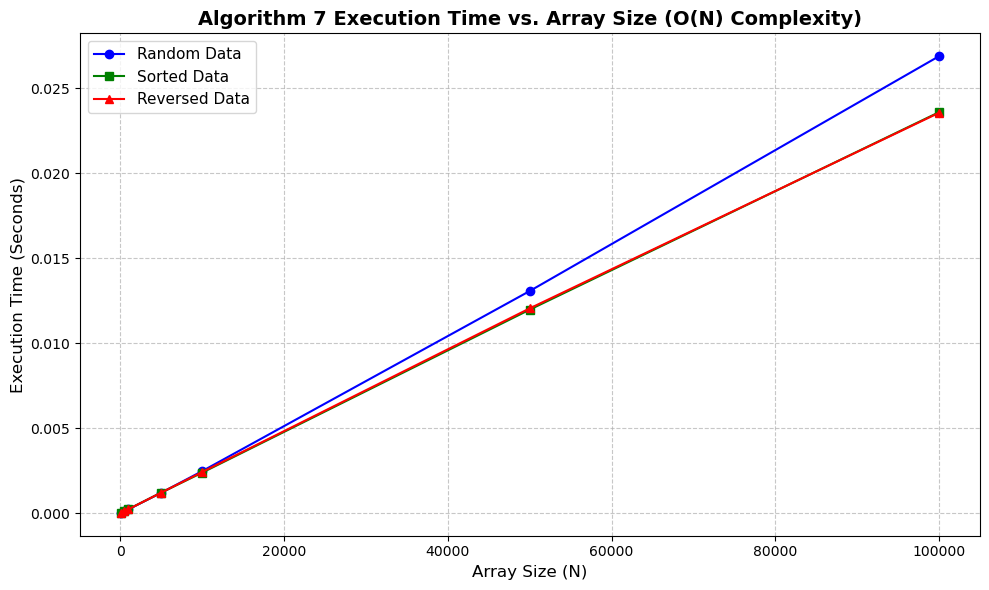

In [19]:
benchmark()

As the graph suggests, the time complexity is visually linear with the input size $N$